In [3]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import rdp
import networkx as nx

import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
# import cfpy

In [4]:
from utils.conduits import *
import utils.common
import importlib
importlib.reload(utils.common)
from utils.common import *
from utils.geos import * 

In [4]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [64]:
top =np.load('../../data/DEM/dem_grid_bear_spring.npy').T
model_parameters['domain']['topography'] = top

In [14]:
for i in range(1):
    app.model.generate(model_parameters)
    # print(app.model.model_parameters['sks']['seed'])


In [112]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
edges.columns = ['from_id', 'to_id']

In [ ]:
#conduit activation network generation
import json
with open("graph.json") as f:
    data = json.load(f)

node_rows = []
for node_id, node_info in data["nodes"].items():
    pos = node_info.get("position", {})
    node_rows.append({
        "id": node_info["data"]["id"],
        "x": pos.get("x"),
        "y": pos.get("y"),
        "z": pos.get("z"),
    })

nodes_df = pd.DataFrame(node_rows)

# ---- EDGES ----
edge_rows = []
for edge_id, edge_info in data["edges"].items():
    ed = edge_info["data"]
    edge_rows.append({
        "id": ed.get("id"),
        "from_id": ed.get("source"),
        "to_id": ed.get("target"),
    })

edges_df = pd.DataFrame(edge_rows)

# Create mapping from old IDs → new integer IDs
unique_nodes = nodes_df['id'].unique()
id_map = {old: i for i, old in enumerate(unique_nodes)}

# Apply mapping to nodes
nodes_df['old_id'] = nodes_df['id']
nodes_df['id'] = nodes_df['id'].map(id_map)

# Update edge endpoints
edges_df['from_id'] = edges_df['from_id'].map(id_map)
edges_df['to_id']   = edges_df['to_id'].map(id_map)


In [5]:
def densify_edges_3d(nodes, edges, n_interp=3):
    """
    Densify a 3D graph network by adding n_interp evenly spaced
    points along each edge (without changing shape).
    
    nodes: DataFrame with columns ['id','x','y','z']
    edges: DataFrame with columns ['from_id','to_id']
    n_interp: number of interior nodes to insert per edge
    """

    new_nodes = []
    new_edges = []

    next_id = nodes['id'].max() + 1

    for _, row in edges.iterrows():
        # original endpoints
        n1 = nodes.loc[nodes['id'] == row['from_id']].iloc[0]
        n2 = nodes.loc[nodes['id'] == row['to_id']].iloc[0]

        x1, y1, z1 = n1['x'], n1['y'], n1['z']
        x2, y2, z2 = n2['x'], n2['y'], n2['z']

        # Create interpolated nodes
        interp_ids = []
        for k in range(1, n_interp + 1):
            t = k / (n_interp + 1)

            x = (1 - t) * x1 + t * x2
            y = (1 - t) * y1 + t * y2
            z = (1 - t) * z1 + t * z2

            new_nodes.append([next_id, x, y, z])
            interp_ids.append(next_id)
            next_id += 1

        # Subdivide the edge into smaller edges
        pts = [row['from_id']] + interp_ids + [row['to_id']]
        for a, b in zip(pts[:-1], pts[1:]):
            new_edges.append([a, b])

    # 
    new_nodes_df = pd.DataFrame(new_nodes, columns=['id','x','y','z'])
    new_nodes_df['type'] = 'junction'  # add type column
    dense_nodes = pd.concat(
        [nodes, new_nodes_df],
        ignore_index=True
    )

    dense_edges = pd.DataFrame(new_edges, columns=['from_id','to_id'])

    return dense_nodes, dense_edges

In [13]:
nodes = pd.read_csv("../../data/networks/conduit_activation/nodes.csv").dropna()
edges = pd.read_csv("../../data/networks/conduit_activation/edges.csv").dropna()
nodes['id'] = nodes.id.astype(int)
edges['from_id'] = edges.from_id.astype(int)
edges['to_id'] = edges.to_id.astype(int)

In [14]:
nodes, edges = densify_edges_3d(nodes, edges, n_interp=4)

In [19]:
nodes.to_csv('../../data/networks/conduit_activation/n_26_nodes.csv', index=False)
edges.to_csv('../../data/networks/conduit_activation/n_26_edges.csv', index=False)

In [82]:
import networkx as nx
import numpy as np


def generate_polylines(nodes, edges):
    def get_polylines(G):
        polylines = []
        visited = set()
        for node in G.nodes():
            if G.degree(node) != 2:   # start only at ends or junctions
                for nbr in G.neighbors(node):
                    if (node, nbr) in visited or (nbr, node) in visited:
                        continue
                    
                    path = [node, nbr]
                    visited.add((node, nbr))
                    prev, curr = node, nbr

                    while G.degree(curr) == 2:
                        nxt = [n for n in G.neighbors(curr) if n != prev][0]
                        visited.add((curr, nxt))
                        path.append(nxt)
                        prev, curr = curr, nxt

                    polylines.append(path)

        return polylines
    G = nx.Graph()

    # Add nodes with coordinates
    for _, row in nodes.iterrows():
        G.add_node(row['id'], pos=np.array([row['x'], row['y'], row['z']]))
        
    # Add edges
    for _, row in edges.iterrows():
        G.add_edge(row['from_id'], row['to_id'])

    polylines = get_polylines(G)
    polyline_coords = [np.array([G.nodes[n]['pos'] for n in node_list]) for node_list in polylines]
    return polyline_coords

def simplify_polylines(polyline_coords, epsilon):
    simplified_polylines = []
    for coords in polyline_coords:
        simplified = rdp.rdp(coords, epsilon=epsilon)
        simplified_polylines.append(simplified)
    return simplified_polylines

def polylines_to_nodes_edges(polylines, inlets, outlets):
    all_nodes = []
    all_edges = []
    node_id = 0

    for coords in polylines:  # each polyline as Nx3 array
        prev = None
        for xyz in coords:
            all_nodes.append([node_id, xyz[0], xyz[1], xyz[2]])

            if prev is not None:
                all_edges.append([prev, node_id])

            prev = node_id
            node_id += 1

    nodes_df = pd.DataFrame(all_nodes, columns=['id', 'x', 'y', 'z'])
    nodes_df['type'] = ['outlet' if nodes_df.iloc[i][['x', 'y', 'z']].tolist() in outlets else 'inlet' if nodes_df.iloc[i][['x', 'y', 'z']].tolist() in inlets else 'junction' for i in range(len(nodes_df))]
    edges_df = pd.DataFrame(all_edges, columns=['from_id', 'to_id'])

    return nodes_df, edges_df


In [113]:
p =generate_polylines(nodes, edges)
p_simple = simplify_polylines(p, epsilon=.07)
n, e = polylines_to_nodes_edges(p_simple, inlets=nodes[nodes['type']=='inlet'][['x', 'y', 'z']].values.tolist(), outlets=nodes[nodes['type']=='outlet'][['x', 'y', 'z']].values.tolist())

In [ ]:
nodes = nodes_df
edges = edges_df
nodes['z'] = nodes.y
nodes['y'] = 0

In [15]:
edges['y_0'] = nodes.iloc[edges.from_id].reset_index().y
edges['y_1'] = nodes.iloc[edges.to_id].reset_index().y
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x
edges['z_0'] = nodes.iloc[edges.from_id].reset_index().z
edges['z_1'] = nodes.iloc[edges.to_id].reset_index().z

lines = edges[["x_0", "y_0", "z_0", "x_1", "y_1", "z_1"]].values
lines = lines.reshape(-1, 2, 3)

<Axes: xlabel='x', ylabel='z'>

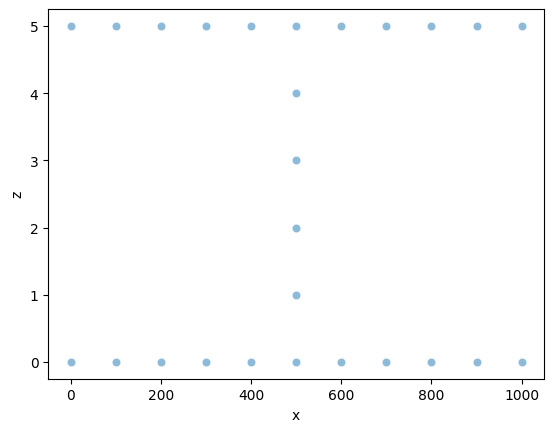

In [16]:
sns.scatterplot(nodes, x='x', y='z', alpha = 0.5)

In [ ]:
app.project._get_simulation_data(11)['maps']['karst']

1

In [136]:
agg_map = None
for i in range(1, app.project.n_simulations):
    print(i)
    results = app.project._get_simulation_data(i)
    if agg_map is None:
        agg_map = results['maps']['karst'][0]
    else:
        agg_map += results['maps']['karst'][0]
agg_map /= app.project.n_simulations

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [17]:
import plotly.graph_objects as go
line_traces = []
for line in lines:
    line_traces.append(
        go.Scatter3d(
            x=line[:,0],
            y=line[:,1],
            z=line[:,2],
            mode='lines',
            line=dict(color='blue', width=1),
            showlegend=False
        )
    )
# node_type_map = {cat: i for i, cat in enumerate(nodes.type.unique())}
# node_colors = nodes.type.map(node_type_map)
# Scatter for nodes
scatter = go.Scatter3d(
    x=nodes.x,
    y=nodes.y,
    z=nodes.z,
    mode='markers',
    marker=dict(
        size=5,
        # color=node_colors,  # categorical or numeric
        colorscale='Viridis',
        showscale=True
    )
)

# Combine and plot
fig = go.Figure(data=line_traces + [scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [34]:
network_path = '../../data/networks/output_dye_trace'
network_agg = None
n = 0
for f in os.listdir(network_path):
    n+=1
    network_dir = f'{network_path}/{f}/network.npy'
    network = np.load(network_dir)
    if network_agg is None:
        network_agg = network
    else:
        network_agg += network
network_agg /= n

Text(0.5, 1.0, 'Conduit distribution, n = 10')

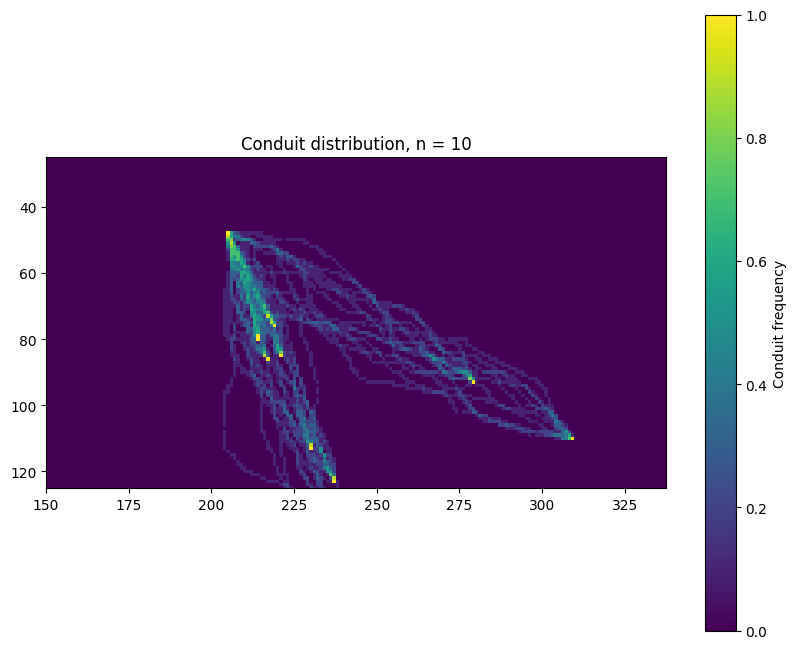

In [ ]:

fig, ax = plt.subplots(figsize = (10,8))
plt.imshow(network_agg)
plt.xlim(150,)
plt.ylim(125,25)
plt.colorbar(label = "Conduit frequency")
plt.title(f"Conduit distribution, n = {n}")
